<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/Linear_Regression_NYC_Taxi_Trip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,recall_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Dataset/nyc_taxi_trip_duration.csv'

In [ ]:
df = pd.read_csv(path)

In [ ]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [ ]:
df.shape

(729322, 11)

In [ ]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,729322.0,1.535403,0.498745,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,729322.0,1.662055,1.312446,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,729322.0,-73.973513,0.069754,-121.933342,-73.991859,-73.981758,-73.967361,-6.589738e+01
pickup_latitude,729322.0,40.750919,0.033594,34.712235,40.737335,40.754070,40.768314,5.188108e+01
dropoff_longitude,729322.0,-73.973422,0.069588,-121.933304,-73.991318,-73.979759,-73.963036,-6.589738e+01
dropoff_latitude,729322.0,40.751775,0.036037,32.181141,40.735931,40.754509,40.769741,4.392103e+01
trip_duration,729322.0,952.229133,3864.626197,1.000000,397.000000,663.000000,1075.000000,1.939736e+06


In [ ]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
df.info()

/tmp/ipykernel_10944/1169376287.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
/tmp/ipykernel_10944/1169376287.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 61.2+ MB


In [ ]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
 11  pickup_hour         729322 non-null  int32         
 12  pickup_day_of_week  729322 non-null  int32         
dtypes: datetime64[ns](2), float64

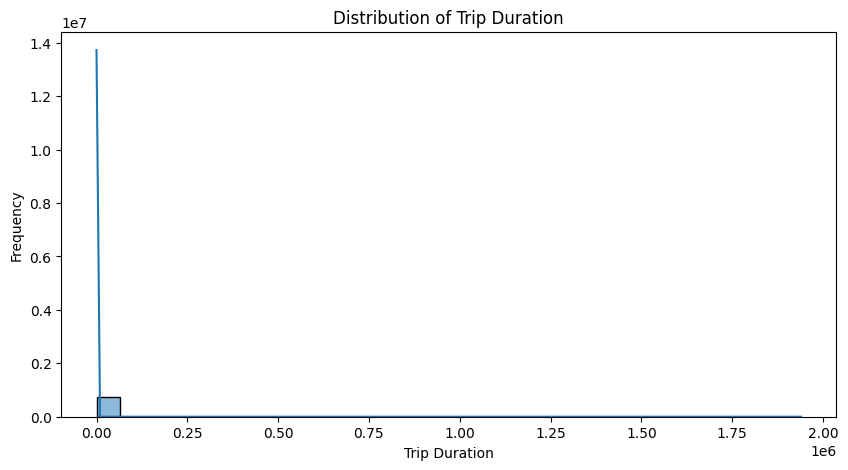

In [ ]:
plt.figure(figsize = (10,5))
sns.histplot(df['trip_duration'], kde = True, bins = 30)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.show()

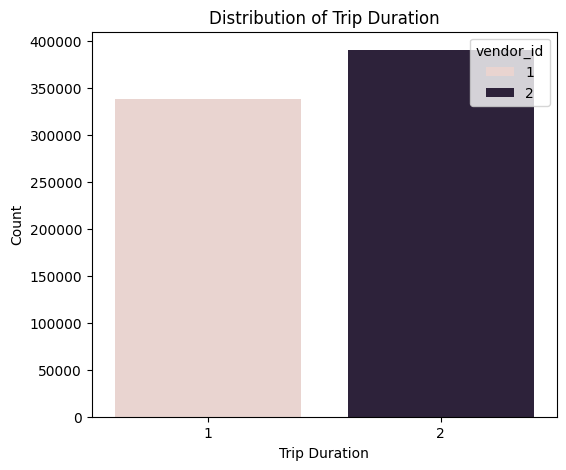

In [ ]:
plt.figure(figsize = (6,5))
sns.countplot(data = df, x = 'vendor_id',hue = 'vendor_id')
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration")
plt.ylabel("Count")
plt.show()

Value count for passenegr_count
passenger_count
1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: count, dtype: int64


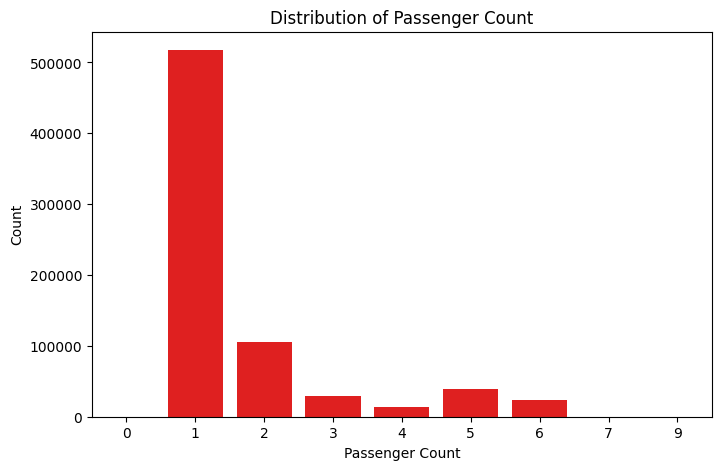

In [ ]:
print('Value count for passenegr_count')
print(df['passenger_count'].value_counts())

plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'passenger_count',color = 'red')
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.show()

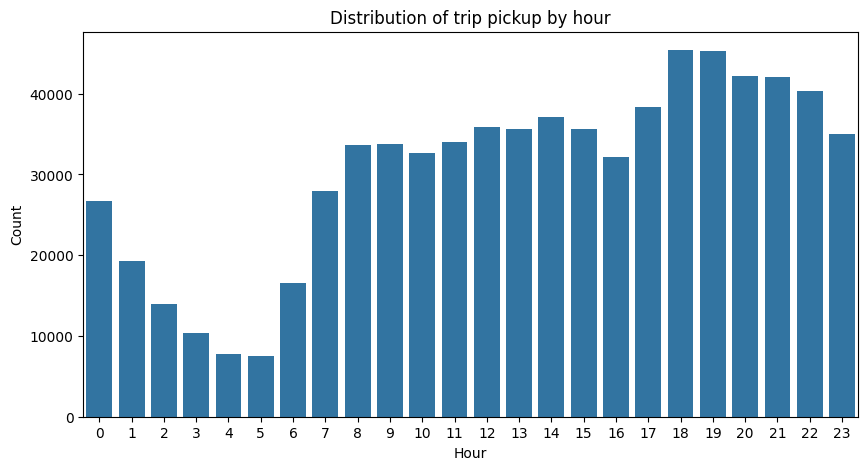

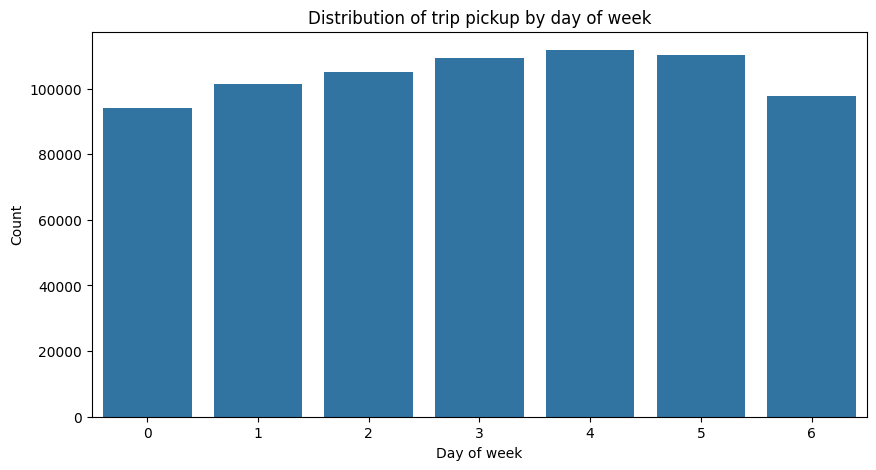

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'pickup_hour')
plt.title('Distribution of trip pickup by hour')
plt.xlabel('Hour')
plt.ylabel('Count')

plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'pickup_day_of_week')
plt.title('Distribution of trip pickup by day of week')
plt.xlabel('Day of week')
plt.ylabel('Count')
plt.show()

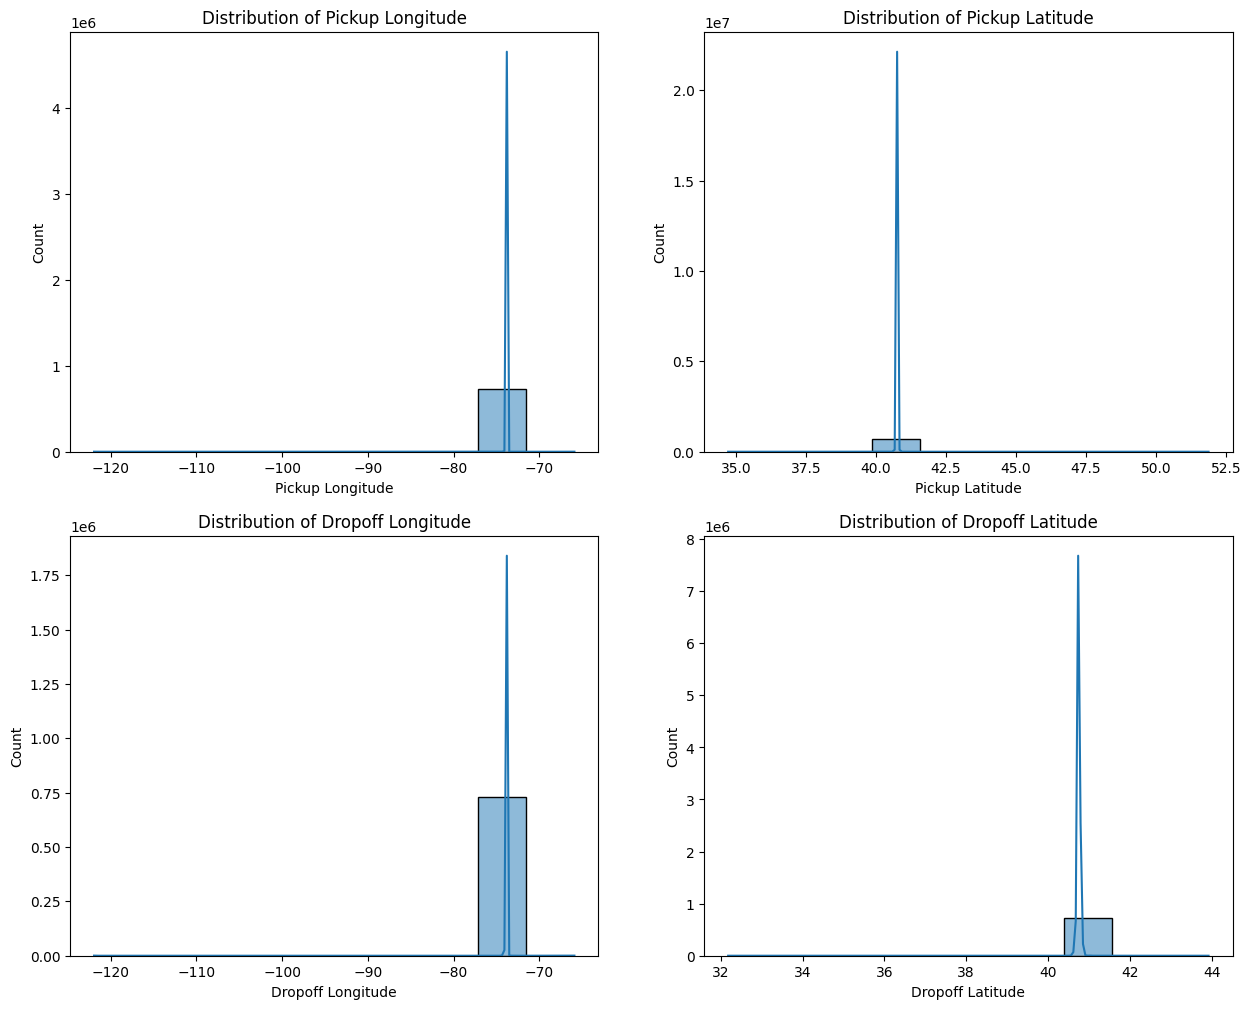

In [ ]:
plt.figure(figsize = (15,12))
plt.subplot(2,2,1)
sns.histplot(data = df, x = 'pickup_longitude', kde = True, bins = 10)
plt.title('Distribution of Pickup Longitude')
plt.xlabel("Pickup Longitude")

plt.subplot(2,2,2)
sns.histplot(data = df, x = 'pickup_latitude', kde = True, bins = 10)
plt.title('Distribution of Pickup Latitude')
plt.xlabel('Pickup Latitude')

plt.subplot(2,2,3)
sns.histplot(data = df, x = 'dropoff_longitude', kde = True, bins = 10)
plt.title('Distribution of Dropoff Longitude')
plt.xlabel('Dropoff Longitude')

plt.subplot(2,2,4)
sns.histplot(data = df, x = 'dropoff_latitude', kde = True, bins = 10)
plt.title('Distribution of Dropoff Latitude')
plt.xlabel('Dropoff Latitude')
plt.show()

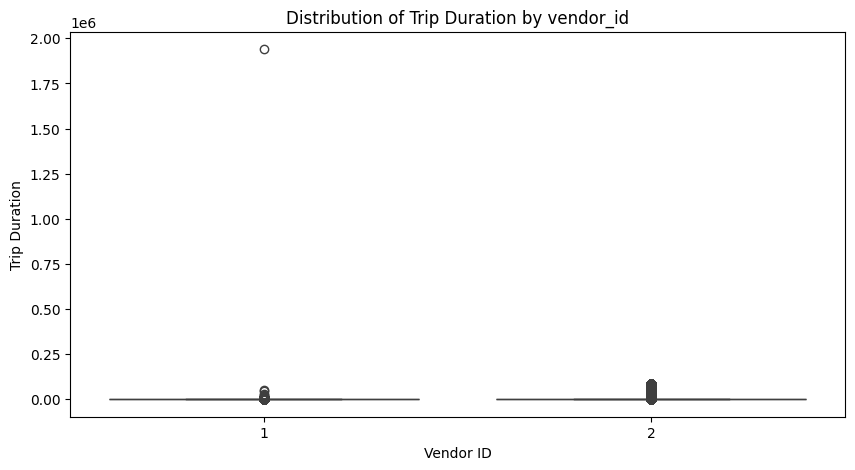

In [ ]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'vendor_id', y = 'trip_duration')
plt.title('Distribution of Trip Duration by vendor_id')
plt.xlabel('Vendor ID')
plt.ylabel('Trip Duration')
plt.show()

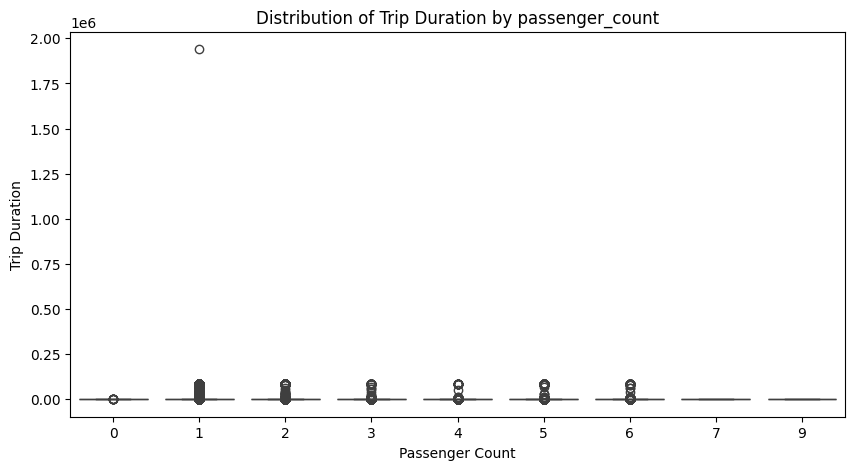

In [ ]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = 'passenger_count', y = 'trip_duration')
plt.title('Distribution of Trip Duration by passenger_count')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Duration')
plt.show()

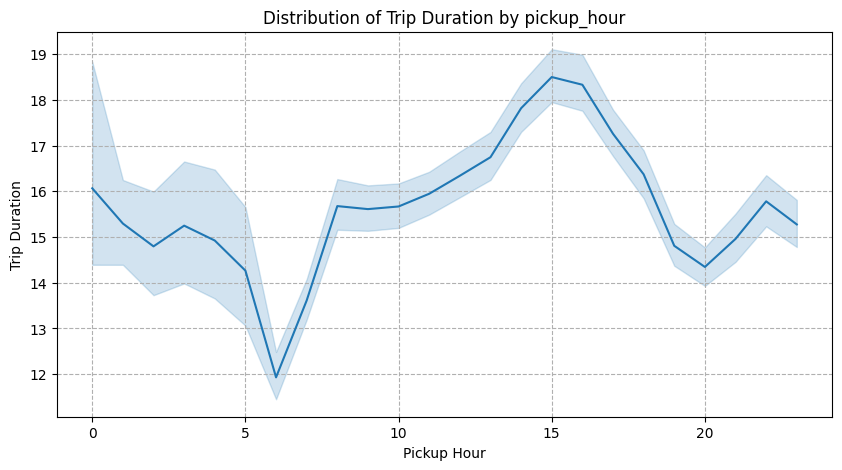

In [ ]:
plt.figure(figsize = (10,5))
sns.lineplot(data = df, x = 'pickup_hour', y = df['trip_duration']/60)
plt.title('Distribution of Trip Duration by pickup_hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Trip Duration')
plt.grid(True,linestyle = '--')
plt.show()

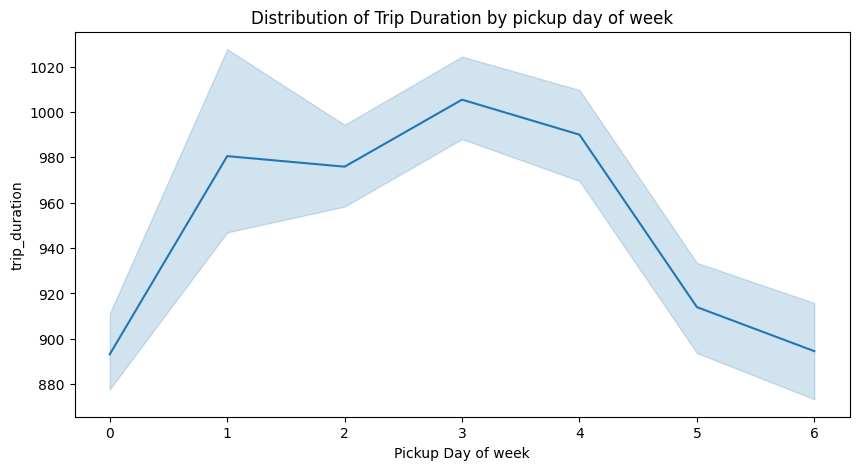

In [ ]:
plt.figure(figsize = (10,5))
sns.lineplot(data = df, x = 'pickup_day_of_week', y = 'trip_duration')
plt.title('Distribution of Trip Duration by pickup day of week')
plt.xlabel('Pickup Day of week')
plt.show()

<Figure size 1500x1500 with 0 Axes>

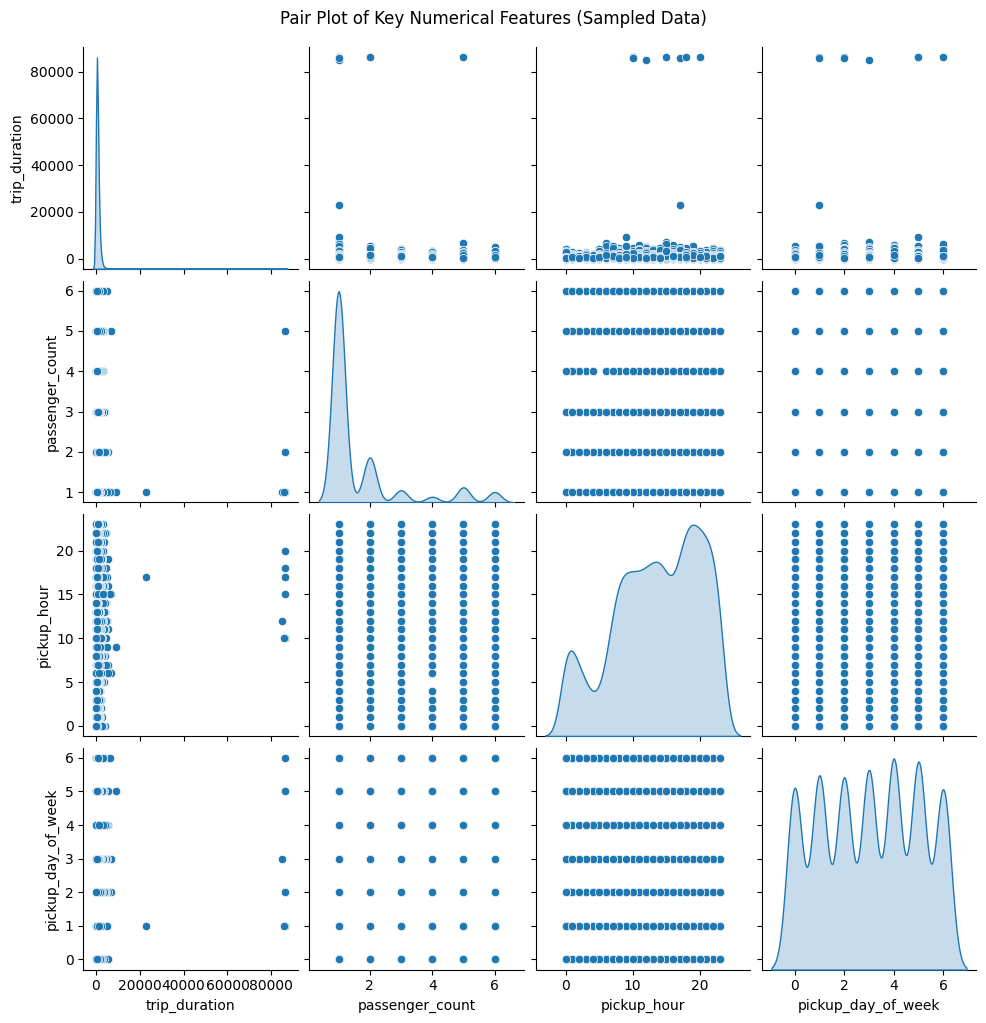

In [ ]:
pairplot = ['trip_duration', 'passenger_count', 'pickup_hour', 'pickup_day_of_week']
df_pairplot = df[pairplot].copy()
df_pairplot_sample = df_pairplot.sample(n=10000, random_state=42)
plt.figure(figsize=(15, 15))
sns.pairplot(df_pairplot_sample, diag_kind='kde')
plt.suptitle('Pair Plot of Key Numerical Features (Sampled Data)', y=1.02)
plt.show()

<Axes: >

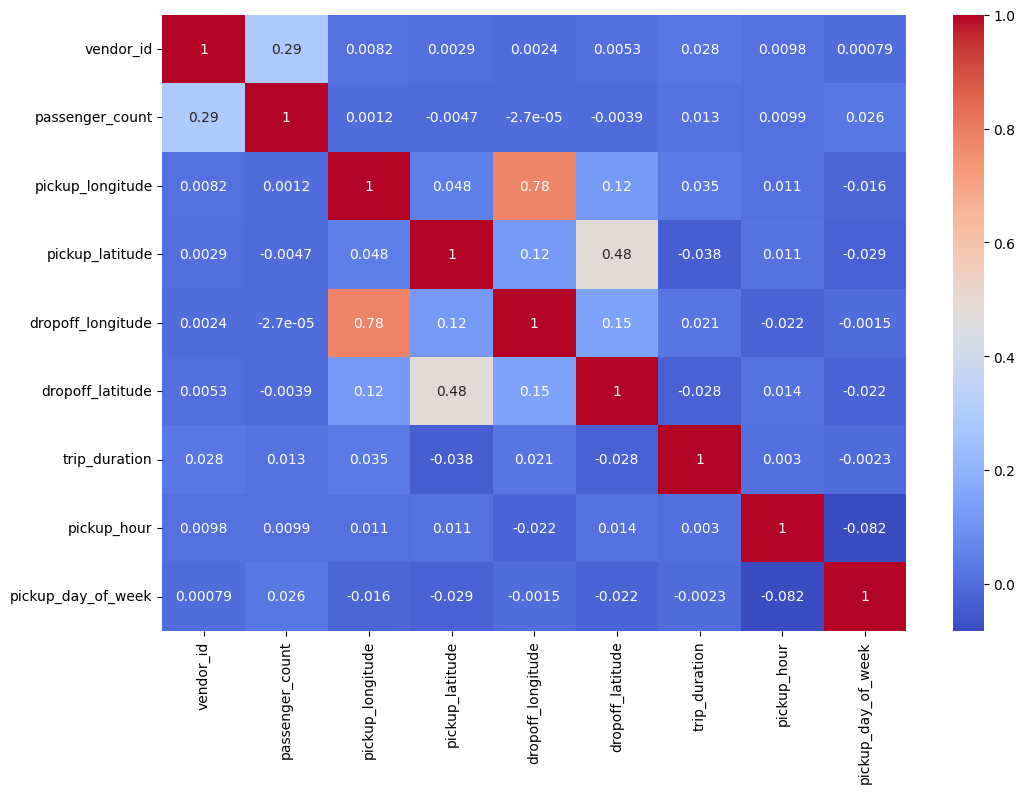

In [ ]:
plt.figure(figsize = (12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot = True, cmap = 'coolwarm')

Original trip_duration min: 1
Original trip_duration max: 1939736
Lower bound (0.01 percentile): 2.0
Upper bound (99.99 percentile): 86327.0

Shape before filtering trip_duration outliers: (728564, 14)
Shape after filtering trip_duration outliers: (728564, 14)

Descriptive statistics for filtered trip_duration:
count    728564.000000
mean        939.998796
std        3009.266665
min           2.000000
25%         397.000000
50%         663.000000
75%        1074.000000
max       86327.000000
Name: trip_duration, dtype: float64


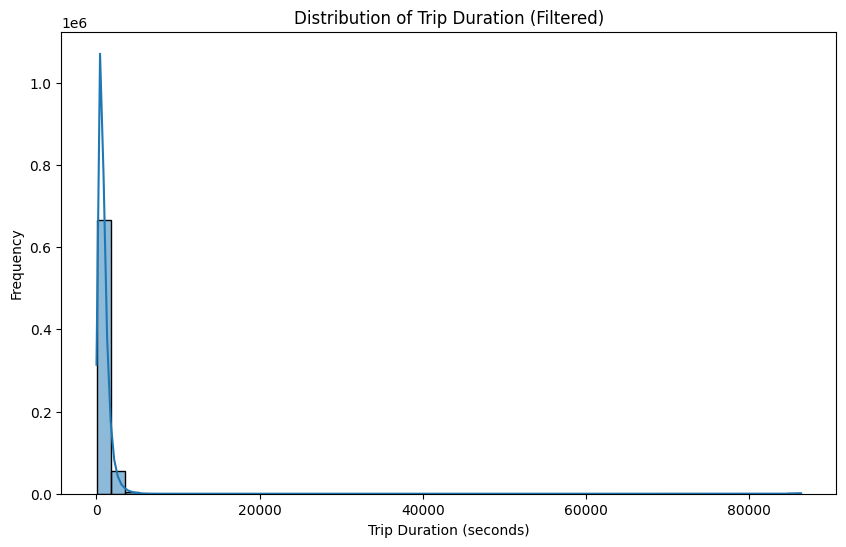

In [ ]:
lower_bound = df['trip_duration'].quantile(0.0001)
upper_bound = df['trip_duration'].quantile(0.9999)

print(f"Original trip_duration min: {df['trip_duration'].min()}")
print(f"Original trip_duration max: {df['trip_duration'].max()}")
print(f"Lower bound (0.01 percentile): {lower_bound}")
print(f"Upper bound (99.99 percentile): {upper_bound}")

# Filter out outliers
df = df[(df['trip_duration'] >= lower_bound) & (df['trip_duration'] <= upper_bound)].copy()

print(f"\nShape before filtering trip_duration outliers: {df.shape}")
print(f"Shape after filtering trip_duration outliers: {df.shape}")

# Re-check descriptive statistics after filtering
print('\nDescriptive statistics for filtered trip_duration:')
print(df['trip_duration'].describe())

# Visualize the distribution after filtering
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration (Filtered)')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()


Shape after filtering passenger_count outliers: (728564, 14)

Value counts for filtered passenger_count:
passenger_count
1    516873
2    105004
5     38895
3     29666
6     24090
4     14036
Name: count, dtype: int64

Descriptive statistics for filtered passenger_count:
count    728564.000000
mean          1.662226
std           1.312496
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: passenger_count, dtype: float64


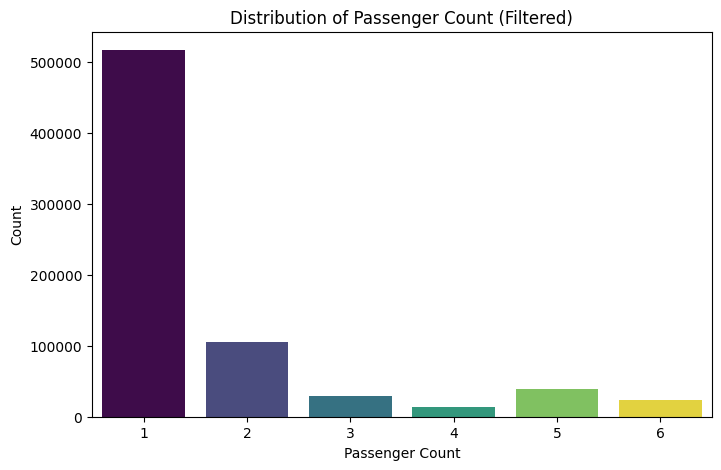

In [ ]:
# Remove trips with 0 passengers
df = df[df['passenger_count'] > 0].copy()

# Additionally, cap passenger count to a reasonable maximum (e.g., 6 passengers for a larger taxi/van).
# We will filter out counts greater than 6.
df = df[df['passenger_count'] <= 6].copy()

print(f"\nShape after filtering passenger_count outliers: {df.shape}")

# Re-check value counts and descriptive statistics for passenger_count
print('\nValue counts for filtered passenger_count:')
print(df['passenger_count'].value_counts())
print('\nDescriptive statistics for filtered passenger_count:')
print(df['passenger_count'].describe())

# Visualize the distribution after filtering
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', data=df, palette='viridis', hue='passenger_count', legend=False)
plt.title('Distribution of Passenger Count (Filtered)')
plt.xlabel('Passenger Count')
plt.ylabel('Count')
plt.show()

In [ ]:
# Define NYC bounding box coordinates
# These are approximate bounds for New York City and surrounding areas.
NYC_BOUNDS = {
    'min_longitude': -74.25,
    'max_longitude': -73.70,
    'min_latitude': 40.50,
    'max_latitude': 40.92
}

# Filter out trips where pickup or dropoff coordinates are outside the NYC bounding box
df = df[
    (df['pickup_longitude'] >= NYC_BOUNDS['min_longitude']) &
    (df['pickup_longitude'] <= NYC_BOUNDS['max_longitude']) &
    (df['pickup_latitude'] >= NYC_BOUNDS['min_latitude']) &
    (df['pickup_latitude'] <= NYC_BOUNDS['max_latitude']) &
    (df['dropoff_longitude'] >= NYC_BOUNDS['min_longitude']) &
    (df['dropoff_longitude'] <= NYC_BOUNDS['max_longitude']) &
    (df['dropoff_latitude'] >= NYC_BOUNDS['min_latitude']) &
    (df['dropoff_latitude'] <= NYC_BOUNDS['max_latitude'])
].copy()

print(f"\nShape after filtering geographical outliers: {df.shape}")

# Re-check descriptive statistics for geographical features after filtering
print('\nDescriptive statistics for pickup_longitude (Filtered):')
print(df['pickup_longitude'].describe())
print('\nDescriptive statistics for pickup_latitude (Filtered):')
print(df['pickup_latitude'].describe())


Shape after filtering geographical outliers: (728564, 14)

Descriptive statistics for pickup_longitude (Filtered):
count    728564.000000
mean        -73.973541
std           0.037960
min         -74.225800
25%         -73.991867
50%         -73.981766
75%         -73.967400
max         -73.703575
Name: pickup_longitude, dtype: float64

Descriptive statistics for pickup_latitude (Filtered):
count    728564.000000
mean         40.750930
std           0.027955
min          40.520481
25%          40.737354
50%          40.754074
75%          40.768311
max          40.914124
Name: pickup_latitude, dtype: float64


## Distance Features

In [ ]:
R = 6371  #Redius of earth in KM.

lat1 = np.radians(df['pickup_latitude'])
lon1 = np.radians(df['pickup_longitude'])
lat2 = np.radians(df['dropoff_latitude'])
lon2 = np.radians(df['dropoff_longitude'])

# Differences
dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
c = 2 * np.arcsin(np.sqrt(a))
df['distance_km'] = R * c

print("Distance calculated using Vectorization:")
print(df[['pickup_latitude', 'pickup_longitude','dropoff_latitude','dropoff_longitude', 'distance_km']].head())

Distance calculated using Vectorization:
   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0        40.778873        -73.953918         40.771164         -73.963875   
1        40.731743        -73.988312         40.694931         -73.994751   
2        40.721458        -73.997314         40.774918         -73.948029   
3        40.759720        -73.961670         40.780628         -73.956779   
4        40.708469        -74.017120         40.740631         -73.988182   

   distance_km  
0     1.199072  
1     4.129111  
2     7.250752  
3     2.361097  
4     4.328533  


### Speed Feature

In [ ]:
# Calculate speed in km.
df['speed_kmh'] = (df['distance_km'] / (df['trip_duration'] / 3600))

# Handle potential infinite or NaN values that could arise from distance_km = 0 or trip_duration = 0
df['speed_kmh'] = df['speed_kmh'].replace([np.inf, -np.inf], np.nan)
df['speed_kmh'] = df['speed_kmh'].fillna(0) # Replace NaN (e.g., for 0-distance trips) with 0 speed

print("Speed (km/h) calculated. Displaying first few rows with new feature:")
print(df[['trip_duration', 'distance_km', 'speed_kmh']].head())

# Check descriptive statistics for speed_kmh
print('\nDescriptive statistics for speed_kmh:')
print(df['speed_kmh'].describe())

Speed (km/h) calculated. Displaying first few rows with new feature:
   trip_duration  distance_km  speed_kmh
0            400     1.199072  10.791651
1           1100     4.129111  13.513455
2           1635     7.250752  15.964959
3           1141     2.361097   7.449560
4            848     4.328533  18.375850

Descriptive statistics for speed_kmh:
count    728564.000000
mean         14.383317
std           8.704536
min           0.000000
25%           9.125170
50%          12.793964
75%          17.830015
max        1410.023567
Name: speed_kmh, dtype: float64


In [ ]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day_of_week,distance_km,speed_kmh
0,2,2016-02-29 16:40:00,2016-02-29 16:47:00,1,-73.953918,40.778873,-73.963875,40.771164,N,400,16,0,1.199072,10.791651
1,1,2016-03-11 23:35:00,2016-03-11 23:53:00,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,23,4,4.129111,13.513455
2,2,2016-02-21 17:59:00,2016-02-21 18:26:00,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,17,6,7.250752,15.964959
3,2,2016-01-05 09:44:00,2016-01-05 10:03:00,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,9,1,2.361097,7.449560
4,1,2016-02-17 06:42:00,2016-02-17 06:56:00,1,-74.017120,40.708469,-73.988182,40.740631,N,848,6,2,4.328533,18.375850


### Define Feature and Target

In [ ]:
df.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day_of_week,distance_km,speed_kmh
0,2,2016-02-29 16:40:00,2016-02-29 16:47:00,1,-73.953918,40.778873,-73.963875,40.771164,N,400,16,0,1.199072,10.791651
1,1,2016-03-11 23:35:00,2016-03-11 23:53:00,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,23,4,4.129111,13.513455
2,2,2016-02-21 17:59:00,2016-02-21 18:26:00,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,17,6,7.250752,15.964959
3,2,2016-01-05 09:44:00,2016-01-05 10:03:00,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,9,1,2.361097,7.449560
4,1,2016-02-17 06:42:00,2016-02-17 06:56:00,1,-74.017120,40.708469,-73.988182,40.740631,N,848,6,2,4.328533,18.375850


In [ ]:
feature = ['vendor_id', 'passenger_count',
            'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'pickup_hour', 'pickup_day_of_week', 'pickup_day', 'pickup_month', 'pickup_year', 'pickup_week_of_year',
            'distance_km', 'speed_kmh']

In [ ]:
x = df[feature]
y = df['trip_duration']

In [ ]:
print(f" X Shape = {x.shape}")
print(f"Y Shape = {y.shape}")

 X Shape = (728564, 14)
Y Shape = (728564,)


### Data Split

We'll split the data into training and testing sets to evaluate our model's ability to generalize to unseen data.

In [ ]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train Shape = {x_train.shape}")
print(f"X_test Shape = {x_test.shape}")
print(f"Y_train Shape = {y_train.shape}")
print(f"Y_test Shape = {y_test.shape}")

X_train Shape = (582851, 14)
X_test Shape = (145713, 14)
Y_train Shape = (582851,)
Y_test Shape = (145713,)


### Choose a Model & Train the Model

For this problem, a Gradient Boosting Regressor (e.g., LightGBM or XGBoost) is a good choice due to its performance and ability to handle various data types. We'll use LightGBM for its speed and efficiency.

In [ ]:
# Initialize the LightGBM Regressor model
lgb_model = lgb.LGBMRegressor(objective='regression_l1', # MAE objective
                              metric='rmse',
                              n_estimators=1000,
                              learning_rate=0.05,
                              num_leaves=31,
                              max_depth=-1,
                              min_child_samples=20,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42,
                              n_jobs=-1)

print("Training LightGBM model...")
# Train the model
lgb_model.fit(x_train, y_train,
              eval_set=[(x_test, y_test)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

print("Model training complete.")

Training LightGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 582851, number of used features: 13
[LightGBM] [Info] Start training from score 662.000000
Model training complete.


Model Evaluation on Test Set:
RMSE: 686.5688
MAE: 27.9177
R-squared: 0.9490


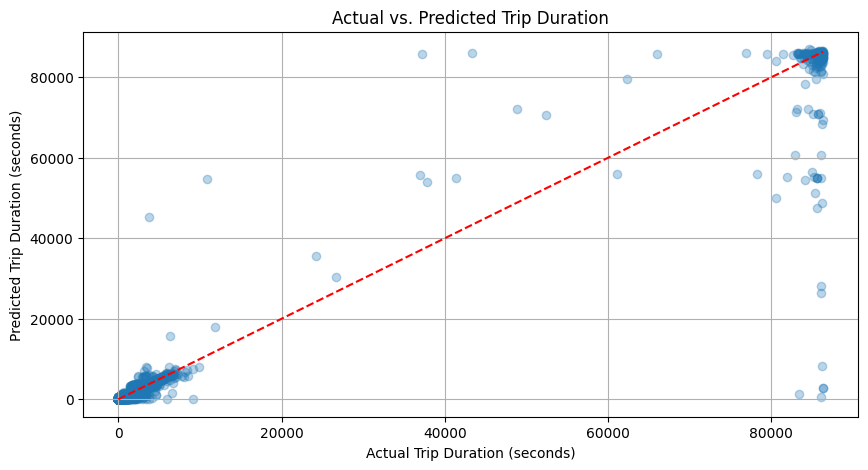

In [ ]:
# Make predictions on the test set
y_pred = lgb_model.predict(x_test)

# Ensure predictions are non-negative
y_pred[y_pred < 0] = 0

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Model Evaluation on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")


# Visualize predictions vs actual values (sample)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Actual vs. Predicted Trip Duration')
plt.grid(True)
plt.show()

### Linear Regression Model

In [ ]:
# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(x_train, y_train)

LinearRegression()

### Evaluate the Model

Linear Regression Model Evaluation on Test Set:
RMSE: 2944.6291
MAE: 333.3055
R-squared: 0.0623


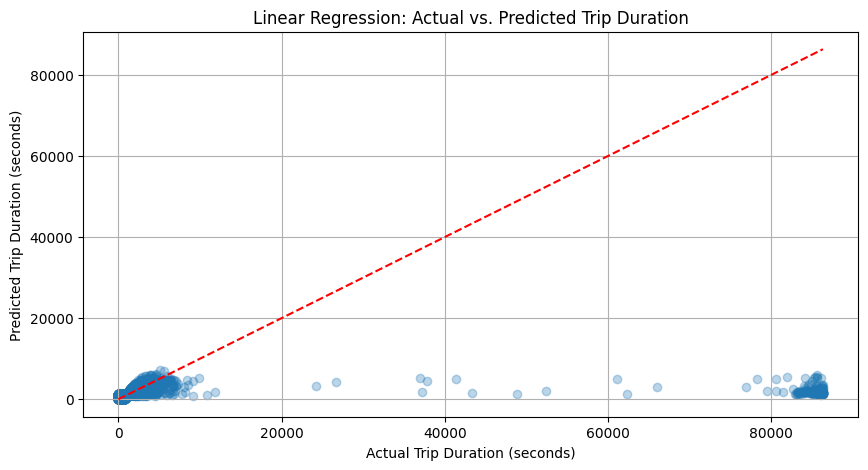

In [ ]:
# Make predictions on the test set
y_pred_linear = linear_model.predict(x_test)

# Ensure predictions are non-negative
y_pred_linear[y_pred_linear < 0] = 0

# Evaluate the model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression Model Evaluation on Test Set:")
print(f"RMSE: {rmse_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")
print(f"R-squared: {r2_linear:.4f}")
`
# Visualize predictions vs actual values (sample)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_linear, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Linear Regression: Actual vs. Predicted Trip Duration')
plt.grid(True)
plt.show()